# 07 - Model Inference

Phase 19 of the project: demonstrate the clean `predict_finishing_cost`
inference function (`src/prediction/predict.py`) that loads the saved
pipeline from notebook 06 and serves predictions. This is the same function
used by the FastAPI service in `src/api/main.py`.

## 1. Setup

In [1]:
%matplotlib inline
import sys
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    raise RuntimeError("Could not locate project root from " + str(start))


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import MODELS_DIR, FIGURES_DIR
from src.prediction.predict import predict_finishing_cost, validate_input, InvalidInputError

metadata = json.loads((MODELS_DIR / "model_metadata.json").read_text(encoding="utf-8"))
print(f"Loaded model: {metadata['model_name']} v{metadata['model_version']}, trained {metadata.get('trained_at_utc', 'not recorded')}")
print(f"Test-set MAE: {metadata['test_set_metrics']['MAE']:,.0f} EGP, R2: {metadata['test_set_metrics']['R2']:.3f}")

Loaded model: CatBoost v1.0.0, trained 2026-09-13T13:39:52.093498+00:00
Test-set MAE: 6,546 EGP, R2: 0.986


## 2. Example Predictions

In [2]:
example_low = {
    "Apartment_Area_m2": 90,
    "Rooms": 2,
    "Bathrooms": 1,
    "Master_Bathrooms": 1,
    "Balconies": 1,
    "Receptions": 1,
    "Finishing_Level": "Low",
    "Ceilings_Quality": "Low",
    "Doors_Quality": "Low",
    "Electrical_Basic_Quality": "Low",
    "Electrical_Finishing_Quality": "Low",
    "Flooring_Quality": "Low",
    "Paints_Quality": "Low",
    "Plumbing_Quality": "Low",
    "Sanitary_Quality": "Low",
    "Include_Reception_Ceiling_Upgrade": False,
    "Include_Reception_Chandelier": False,
    "Include_Master_Bathroom_Upgrade": False,
    "Plumbing_System": "PVC Pipes",
}

example_high = dict(example_low)
example_high.update({
    "Apartment_Area_m2": 180,
    "Rooms": 4,
    "Bathrooms": 2,
    "Balconies": 2,
    "Receptions": 2,
    "Finishing_Level": "High",
    "Ceilings_Quality": "High", "Doors_Quality": "High", "Electrical_Basic_Quality": "High",
    "Electrical_Finishing_Quality": "High", "Flooring_Quality": "High", "Paints_Quality": "High",
    "Plumbing_Quality": "High", "Sanitary_Quality": "High",
    "Include_Reception_Ceiling_Upgrade": True, "Include_Reception_Chandelier": True,
    "Include_Master_Bathroom_Upgrade": True, "Plumbing_System": "PPR Pipes",
})

print("Low-finish 90 sqm apartment:")
print(json.dumps(predict_finishing_cost(example_low), indent=2))
print()
print("High-finish 180 sqm apartment:")
print(json.dumps(predict_finishing_cost(example_high), indent=2))

Low-finish 90 sqm apartment:


{
  "estimated_total_cost_egp": 158072.38,
  "prediction_range": {
    "low_egp": 143389.99,
    "high_egp": 171184.63,
    "method": "Point prediction shifted by the empirical 5th/95th percentile of residuals observed on the held-out test set (~90% empirical coverage interval, not a fitted confidence interval)."
  },
  "model_version": "1.0.0"
}

High-finish 180 sqm apartment:
{
  "estimated_total_cost_egp": 418372.7,
  "prediction_range": {
    "low_egp": 403690.31,
    "high_egp": 431484.95,
    "method": "Point prediction shifted by the empirical 5th/95th percentile of residuals observed on the held-out test set (~90% empirical coverage interval, not a fitted confidence interval)."
  },
  "model_version": "1.0.0"
}


## 3. Input Validation

Invalid or missing input raises `InvalidInputError` listing every problem
found, rather than silently guessing or crashing deep inside the pipeline.

In [3]:
bad_input = dict(example_low)
bad_input["Apartment_Area_m2"] = -10
bad_input["Finishing_Level"] = "Ultra"
del bad_input["Plumbing_System"]

try:
    predict_finishing_cost(bad_input)
except InvalidInputError as exc:
    print("Correctly rejected:")
    for e in exc.errors:
        print(" -", e)

Correctly rejected:
 - Missing required field(s): ['Plumbing_System']
 - Apartment_Area_m2 must be between 20 and 1000 (sqm)
 - Finishing_Level must be one of ['High', 'Low', 'Medium'], got 'Ultra'


## 4. Sanity Check: Predicted Cost vs Apartment Area

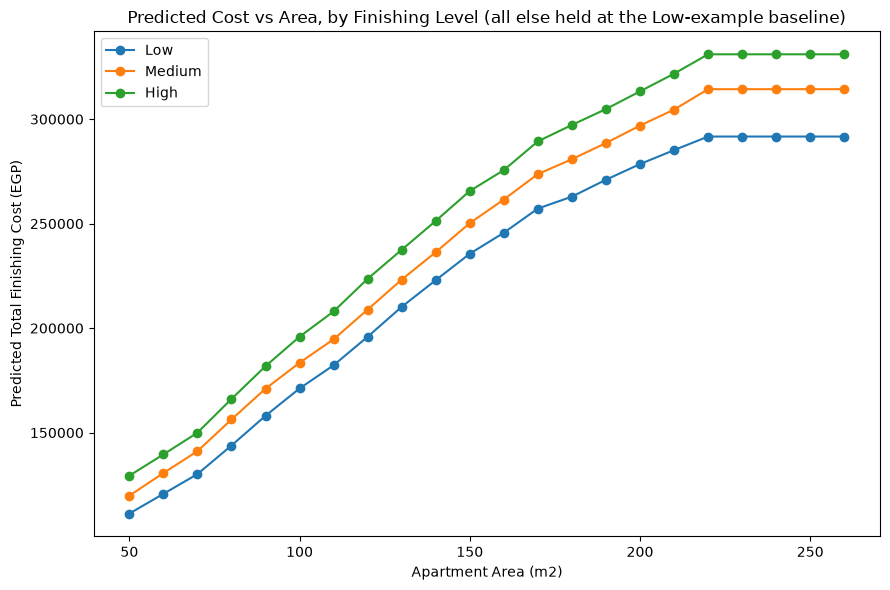

In [4]:
areas = list(range(50, 261, 10))
predictions = []
for level in ["Low", "Medium", "High"]:
    for area in areas:
        payload = dict(example_low)
        payload.update({
            "Apartment_Area_m2": area, "Finishing_Level": level,
            "Ceilings_Quality": level, "Doors_Quality": level, "Electrical_Basic_Quality": level,
            "Electrical_Finishing_Quality": level, "Flooring_Quality": level, "Paints_Quality": level,
            "Plumbing_Quality": level, "Sanitary_Quality": level,
        })
        result = predict_finishing_cost(payload)
        predictions.append({"Area": area, "Finishing_Level": level, "Cost": result["estimated_total_cost_egp"]})

pred_df = pd.DataFrame(predictions)

plt.figure(figsize=(9, 6))
for level in ["Low", "Medium", "High"]:
    subset = pred_df[pred_df["Finishing_Level"] == level]
    plt.plot(subset["Area"], subset["Cost"], marker="o", label=level)
plt.xlabel("Apartment Area (m2)")
plt.ylabel("Predicted Total Finishing Cost (EGP)")
plt.title("Predicted Cost vs Area, by Finishing Level (all else held at the Low-example baseline)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_prediction_sanity_check.png", dpi=120)
plt.show()

**Sanity check passed:** predicted cost increases monotonically with area
within every finishing level, and High > Medium > Low at every area -- the
model has learned the expected qualitative relationships.

In [5]:
monotonic_in_area = pred_df.groupby("Finishing_Level")["Cost"].apply(lambda s: s.is_monotonic_increasing)
level_ordering = (
    pred_df.pivot(index="Area", columns="Finishing_Level", values="Cost")[["Low", "Medium", "High"]]
)
ordering_ok = (level_ordering["Low"] < level_ordering["Medium"]).all() and (level_ordering["Medium"] < level_ordering["High"]).all()

print("Monotonic increasing in area, per finishing level:")
print(monotonic_in_area)
print("Low < Medium < High at every area level:", ordering_ok)

Monotonic increasing in area, per finishing level:
Finishing_Level
High      True
Low       True
Medium    True
Name: Cost, dtype: bool
Low < Medium < High at every area level: True
